# Full Classification Benchmark

**Classifiers:** KNN, Linear SVM, RBF SVM (C=0.5/1/2), Random Forest, Ward-linkage, MLP

**PCA Dimensions:** 10, 20, 50, 100, None

**Descriptors:** Ord_PI, Inter_PI, 3D_PI, Sixpack_Rips, Sixpack_Chroma, Inter+Ord, 3D+Ord

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, numpy as np, pandas as pd, warnings, time
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import accuracy_score, f1_score
from scipy.optimize import linear_sum_assignment
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/URP'
VECTOR_DIR = os.path.join(BASE, 'Final_Vector')
print(f'Vector dir: {VECTOR_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Vector dir: /content/drive/MyDrive/URP/Final_Vector


## 1. Ground Truth & Soft Accuracy

In [4]:
M1=[[0,0,1,1,1,1,1,1],[0,0,1,1,1,1,1,1],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3]]
M2=[[0,0,1,1,1,1,1,1],[0,0,1,1,1,1,1,1],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,4],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,4,4],[2,2,3,3,3,3,3,3]]
M3=[[6,6,7,7,7,7,7,7],[6,6,6,7,7,7,7,7],[9,6,3,3,3,3,3,3],[9,10,3,4,4,3,3,4],[9,10,3,3,4,4,3,4],[9,10,3,4,4,4,4,4],[9,10,3,4,3,4,4,4],[9,10,3,4,3,4,4,4]]
M4=[[6,6,12,12,7,7,7,7],[6,6,12,12,7,7,7,7],[9,6,6,11,7,7,4,4],[9,9,6,3,3,4,4,4],[9,9,10,3,3,4,4,4],[9,9,10,3,3,4,4,4],[9,9,10,4,4,4,4,4],[9,9,10,4,4,4,4,4]]
M5=[[6,6,12,12,12,12,7,7],[6,6,12,12,12,12,12,7],[9,9,6,11,11,11,12,11],[9,9,6,11,11,11,4,4],[9,9,13,13,4,4,4,4],[9,9,13,10,4,4,4,4],[9,9,13,10,4,4,4,4],[9,9,10,10,4,4,4,4]]
M6=[[6,12,12,12,12,12,12,12],[6,6,12,12,12,12,12,12],[9,6,6,11,11,11,11,11],[9,9,6,11,11,11,11,11],[9,9,6,6,6,13,4,4],[9,9,6,13,13,4,4,4],[9,9,6,13,4,4,4,4],[9,9,6,13,4,4,4,4]]
M7=[[6,6,12,12,12,12,12,12],[9,6,12,12,12,12,12,12],[9,6,6,11,11,11,11,12],[9,6,6,11,11,11,11,11],[9,9,6,6,11,11,11,11],[9,9,6,6,11,11,11,4],[9,9,6,6,13,13,4,4],[9,9,6,13,13,4,4,4]]
M8=[[6,12,12,12,12,12,12,12],[6,6,12,12,12,12,12,12],[9,6,6,6,11,11,11,11],[9,6,6,6,11,11,11,11],[9,9,6,6,11,11,11,11],[9,9,6,6,6,11,11,11],[9,9,6,6,13,13,11,11],[9,9,6,6,13,13,11,4]]
GT = np.asarray([M1,M2,M3,M4,M5,M6,M7,M8])

def get_label(task_id):
    idx = task_id - 1
    return GT[idx%64//8][idx//64][idx%8]

# Adjacent phases
def get_adjacent(matrices):
    adj = set()
    for M in matrices:
        M = np.array(M)
        r,c = M.shape
        for i in range(r):
            for j in range(c):
                for di,dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                    ni,nj = i+di, j+dj
                    if 0<=ni<r and 0<=nj<c and M[i,j]!=M[ni,nj]:
                        adj.add(tuple(sorted([int(M[i,j]),int(M[ni,nj])])))
    d = {}
    for p1,p2 in adj:
        d.setdefault(p1,[]).append(p2)
        d.setdefault(p2,[]).append(p1)
    return d

ADJ = get_adjacent(GT)
ALL_CLASSES = sorted(np.unique(GT))
N_CLASSES = len(ALL_CLASSES)

def soft_accuracy(y_true, y_pred):
    n = len(y_true)
    correct = sum(1 for t,p in zip(y_true,y_pred)
                  if t==p or (t in ADJ and p in ADJ[t]))
    return correct/n if n>0 else 0.0

print(f'{N_CLASSES} classes, {len(ADJ)} adjacent entries')

12 classes, 12 adjacent entries


## 2. 데이터 로딩

In [5]:
def load_pi(data_dir, prefix):
    files = sorted(glob.glob(os.path.join(data_dir, f'{prefix}_*.npz')))
    X_list, y_list = [], []
    for fp in files:
        try:
            sim_idx = int(os.path.basename(fp).split('_')[-1].split('.')[0])
            label = get_label(sim_idx)
            data = np.load(fp, allow_pickle=True)
            features = []
            for key in sorted(data.keys()):
                arr = data[key]
                if hasattr(arr,'item') and arr.ndim==0: arr = arr.item()
                if isinstance(arr, dict):
                    for k in sorted(arr.keys()):
                        val = arr[k]
                        if isinstance(val, dict):
                            for dk in sorted(val.keys()): features.extend(np.asarray(val[dk]).flatten())
                        else: features.extend(np.asarray(val).flatten())
                else: features.extend(np.asarray(arr).flatten())
            X_list.append(features); y_list.append(label)
        except Exception as e:
            print(f'  Skip {fp}: {e}')
    if not X_list: return None, None
    return np.nan_to_num(np.array(X_list, dtype=float)), np.array(y_list)

datasets = {}
for name in ['Inter_PI', '3D_PI', 'Ord_PI', 'Sixpack_Rips', 'Sixpack_Chroma']:
    path = os.path.join(VECTOR_DIR, name)
    if os.path.exists(path):
        print(f'Loading {name}...', end=' ')
        X, y = load_pi(path, name)
        if X is not None:
            datasets[name] = {'X': X, 'y': y}
            print(f'{X.shape}')
        else: print('EMPTY')

# 결합 벡터
if 'Inter_PI' in datasets and 'Ord_PI' in datasets:
    datasets['Inter+Ord'] = {
        'X': np.hstack([datasets['Inter_PI']['X'], datasets['Ord_PI']['X']]),
        'y': datasets['Inter_PI']['y']}
    print(f'Inter+Ord: {datasets["Inter+Ord"]["X"].shape}')
if '3D_PI' in datasets and 'Ord_PI' in datasets:
    datasets['3D+Ord'] = {
        'X': np.hstack([datasets['3D_PI']['X'], datasets['Ord_PI']['X']]),
        'y': datasets['3D_PI']['y']}
    print(f'3D+Ord: {datasets["3D+Ord"]["X"].shape}')

METHODS = [m for m in ['Ord_PI','Inter_PI','3D_PI','Sixpack_Rips','Sixpack_Chroma','Inter+Ord','3D+Ord'] if m in datasets]
print(f'\nLoaded: {METHODS}')

Loading Inter_PI... (512, 10200)
Loading 3D_PI... (512, 16800)
Loading Ord_PI... (512, 10200)
Loading Sixpack_Rips... (512, 61200)
Loading Sixpack_Chroma... (512, 61200)
Inter+Ord: (512, 20400)
3D+Ord: (512, 27000)

Loaded: ['Ord_PI', 'Inter_PI', '3D_PI', 'Sixpack_Rips', 'Sixpack_Chroma', 'Inter+Ord', '3D+Ord']


n=512, sqrt(n)=22, k candidates: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
  k= 1: acc=68.56%
  k= 3: acc=74.23%
  k= 5: acc=74.22%
  k= 7: acc=74.42%
  k= 9: acc=73.44%
  k=11: acc=74.42%
  k=13: acc=72.47%
  k=15: acc=72.47%
  k=17: acc=72.47%
  k=19: acc=72.66%
  k=21: acc=72.86%

✓ Best k = 7 (acc=74.42%)


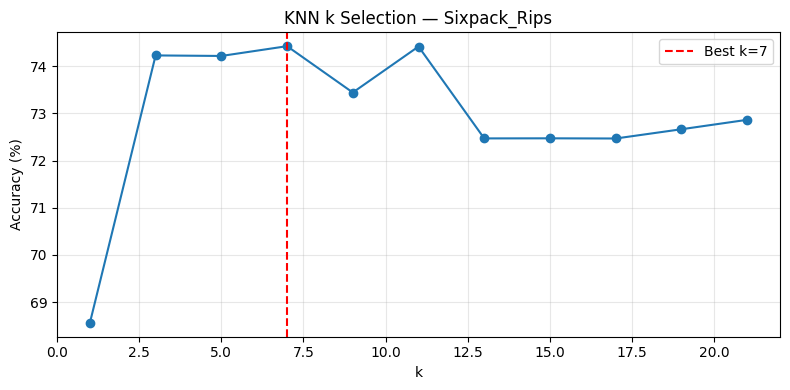

In [6]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 데이터 하나 골라서 테스트 (가장 좋은 descriptor로)
method = 'Sixpack_Rips'  # 변경 가능
X_raw = datasets[method]['X']
y = datasets[method]['y']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X = PCA(n_components=20, random_state=42).fit_transform(X_scaled)

# k 후보: 1, 3, 5, ..., sqrt(n)
n = len(y)
k_max = int(np.sqrt(n))
k_candidates = list(range(1, k_max + 1, 2))  # 홀수만
print(f'n={n}, sqrt(n)={k_max}, k candidates: {k_candidates}')

# 5-fold CV per k
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for k in k_candidates:
    accs = []
    for tr, te in skf.split(X, y):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X[tr], y[tr])
        accs.append(knn.score(X[te], y[te]))
    results[k] = np.mean(accs)
    print(f'  k={k:>2d}: acc={results[k]*100:.2f}%')

best_k = max(results, key=results.get)
print(f'\n✓ Best k = {best_k} (acc={results[best_k]*100:.2f}%)')

# 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(list(results.keys()), [v*100 for v in results.values()], 'o-')
plt.axvline(best_k, color='r', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k'); plt.ylabel('Accuracy (%)'); plt.title(f'KNN k Selection — {method}')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


  k= 1: soft=98.24%  strict=68.56%
  k= 3: soft=98.83%  strict=74.23%
  k= 5: soft=98.64%  strict=74.22%
  k= 7: soft=98.83%  strict=74.42%
  k= 9: soft=99.22%  strict=73.44%
  k=11: soft=98.44%  strict=74.42%
  k=13: soft=98.83%  strict=72.47%
  k=15: soft=98.64%  strict=72.47%
  k=17: soft=99.22%  strict=72.47%
  k=19: soft=99.03%  strict=72.66%
  k=21: soft=98.83%  strict=72.86%

✓ Best k (Soft):   9 (99.22%)
✓ Best k (Strict): 7 (74.42%)


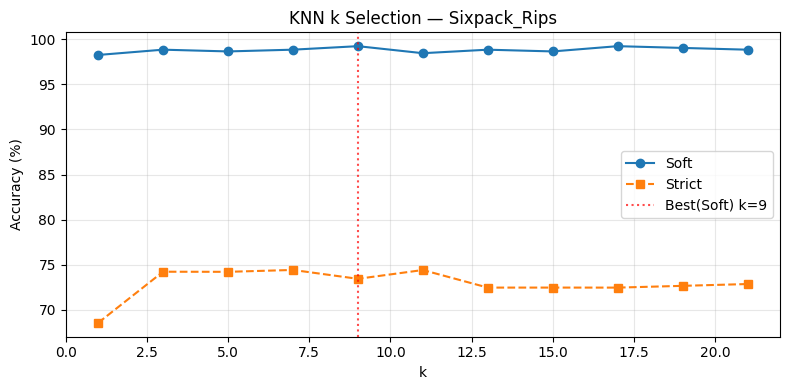

In [7]:
for k in k_candidates:
    soft_accs, strict_accs = [], []
    for tr, te in skf.split(X, y):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X[tr], y[tr])
        yp = knn.predict(X[te])
        strict_accs.append(accuracy_score(y[te], yp))
        soft_accs.append(soft_accuracy(y[te], yp))
    results[k] = {'soft': np.mean(soft_accs), 'strict': np.mean(strict_accs)}
    print(f'  k={k:>2d}: soft={results[k]["soft"]*100:.2f}%  strict={results[k]["strict"]*100:.2f}%')

best_k_soft = max(results, key=lambda k: results[k]['soft'])
best_k_strict = max(results, key=lambda k: results[k]['strict'])
print(f'\n✓ Best k (Soft):   {best_k_soft} ({results[best_k_soft]["soft"]*100:.2f}%)')
print(f'✓ Best k (Strict): {best_k_strict} ({results[best_k_strict]["strict"]*100:.2f}%)')

# 시각화
import matplotlib.pyplot as plt
ks = list(results.keys())
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, [results[k]['soft']*100 for k in ks], 'o-', label='Soft')
ax.plot(ks, [results[k]['strict']*100 for k in ks], 's--', label='Strict')
ax.axvline(best_k_soft, color='r', linestyle=':', alpha=0.7, label=f'Best(Soft) k={best_k_soft}')
ax.set_xlabel('k'); ax.set_ylabel('Accuracy (%)')
ax.set_title(f'KNN k Selection — {method}')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## 3. Classifier 정의

In [9]:
PCA_DIMS = [10, 20, 50, 100, None]
N_SPLITS = 5
RS = 42

def get_classifiers():
    return {
        'KNN(9)':       KNeighborsClassifier(n_neighbors=9),
        'LinearSVM':    SVC(kernel='linear', C=1.0),
        'RBF_C0.5':     SVC(kernel='rbf', C=0.5),
        'RBF_C1.0':     SVC(kernel='rbf', C=1.0),
        'RBF_C2.0':     SVC(kernel='rbf', C=2.0),
        'RF(200)':      RandomForestClassifier(n_estimators=200, random_state=RS),
        'MLP':          MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500,
                                      early_stopping=True, random_state=RS),
    }

# Ward-linkage (비지도 → Hungarian 매핑)
def ward_classify(X, y, n_clusters):
    ward = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cl = ward.fit_predict(X)
    # Hungarian mapping
    ucl, ucs = np.unique(cl), np.unique(y)
    size = max(len(ucl), len(ucs))
    cost = np.zeros((size, size))
    for i, c in enumerate(ucl):
        mask = cl == c
        for j, cs in enumerate(ucs):
            cost[i,j] = np.sum(mask) - np.sum(y[mask] == cs)
    ri, ci = linear_sum_assignment(cost)
    mapping = {ucl[r]: ucs[c] for r,c in zip(ri,ci) if r<len(ucl) and c<len(ucs)}
    y_pred = np.array([mapping.get(c, -1) for c in cl])
    return y_pred

print(f'Classifiers: {list(get_classifiers().keys())} + Ward-linkage')
print(f'PCA dims: {PCA_DIMS}')

Classifiers: ['KNN(9)', 'LinearSVM', 'RBF_C0.5', 'RBF_C1.0', 'RBF_C2.0', 'RF(200)', 'MLP'] + Ward-linkage
PCA dims: [10, 20, 50, 100, None]


## 4. 전체 평가 실행

In [9]:
results = []
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RS)
total_runs = len(METHODS) * len(PCA_DIMS) * (len(get_classifiers()) + 1)  # +1 for Ward
run_count = 0
t_start = time.time()

for method in METHODS:
    X_raw = datasets[method]['X']
    y = datasets[method]['y']

    for pca_dim in PCA_DIMS:
        label_dim = f'PCA{pca_dim}' if pca_dim else 'NoPCA'

        # Preprocess
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_raw)
        if pca_dim is not None and pca_dim < X_scaled.shape[1]:
            X = PCA(n_components=pca_dim, random_state=RS).fit_transform(X_scaled)
        else:
            X = X_scaled

        # ---- Supervised classifiers (5-fold CV) ----
        for clf_name, clf_template in get_classifiers().items():
            fold_soft, fold_strict, fold_f1 = [], [], []
            for tr_idx, te_idx in skf.split(X, y):
                clf = clf_template.__class__(**clf_template.get_params())
                clf.fit(X[tr_idx], y[tr_idx])
                yp = clf.predict(X[te_idx])
                fold_soft.append(soft_accuracy(y[te_idx], yp))
                fold_strict.append(accuracy_score(y[te_idx], yp))
                fold_f1.append(f1_score(y[te_idx], yp, average='macro', zero_division=0))

            results.append({
                'Method': method, 'PCA': label_dim, 'Classifier': clf_name,
                'Soft(%)': np.mean(fold_soft)*100,
                'Strict(%)': np.mean(fold_strict)*100,
                'F1(%)': np.mean(fold_f1)*100,
            })
            run_count += 1

        # ---- Ward-linkage (비지도, 전체 데이터) ----
        yp_ward = ward_classify(X, y, N_CLASSES)
        results.append({
            'Method': method, 'PCA': label_dim, 'Classifier': 'Ward',
            'Soft(%)': soft_accuracy(y, yp_ward)*100,
            'Strict(%)': accuracy_score(y, yp_ward)*100,
            'F1(%)': f1_score(y, yp_ward, average='macro', zero_division=0)*100,
        })
        run_count += 1

        elapsed = time.time() - t_start
        eta = elapsed/run_count*(total_runs-run_count)/60
        print(f'[{run_count:>4d}/{total_runs}] {method} / {label_dim} done (ETA {eta:.0f}min)')

print(f'\nTotal: {(time.time()-t_start)/60:.1f}min')

[   8/280] Ord_PI / PCA10 done (ETA 5min)
[  16/280] Ord_PI / PCA20 done (ETA 4min)
[  24/280] Ord_PI / PCA50 done (ETA 4min)
[  32/280] Ord_PI / PCA100 done (ETA 4min)
[  40/280] Ord_PI / NoPCA done (ETA 11min)
[  48/280] Inter_PI / PCA10 done (ETA 10min)
[  56/280] Inter_PI / PCA20 done (ETA 8min)
[  64/280] Inter_PI / PCA50 done (ETA 8min)
[  72/280] Inter_PI / PCA100 done (ETA 7min)
[  80/280] Inter_PI / NoPCA done (ETA 10min)
[  88/280] 3D_PI / PCA10 done (ETA 9min)
[  96/280] 3D_PI / PCA20 done (ETA 8min)
[ 104/280] 3D_PI / PCA50 done (ETA 7min)
[ 112/280] 3D_PI / PCA100 done (ETA 7min)
[ 120/280] 3D_PI / NoPCA done (ETA 9min)
[ 128/280] Sixpack_Rips / PCA10 done (ETA 8min)
[ 136/280] Sixpack_Rips / PCA20 done (ETA 7min)
[ 144/280] Sixpack_Rips / PCA50 done (ETA 7min)
[ 152/280] Sixpack_Rips / PCA100 done (ETA 6min)
[ 160/280] Sixpack_Rips / NoPCA done (ETA 13min)
[ 168/280] Sixpack_Chroma / PCA10 done (ETA 12min)
[ 176/280] Sixpack_Chroma / PCA20 done (ETA 11min)
[ 184/280] Sixp

## 5. 결과 테이블

In [10]:
df = pd.DataFrame(results)

# 전체 결과 저장
out_path = os.path.join(BASE, 'Final_Results')
os.makedirs(out_path, exist_ok=True)
df.to_csv(os.path.join(out_path, 'full_benchmark.csv'), index=False)
print(f'Saved to {out_path}/full_benchmark.csv\n')

# Best per method × PCA
print('=== Best Classifier per Method × PCA ===')
pivot = df.loc[df.groupby(['Method','PCA'])['Soft(%)'].idxmax()]
pivot = pivot[['Method','PCA','Classifier','Soft(%)','Strict(%)','F1(%)']]
pivot = pivot.sort_values(['Method','PCA']).reset_index(drop=True)
print(pivot.to_string(index=False))

# Best overall per method
print('\n=== Best Overall per Method ===')
best = df.loc[df.groupby('Method')['Soft(%)'].idxmax()]
best = best[['Method','PCA','Classifier','Soft(%)','Strict(%)','F1(%)']]
print(best.to_string(index=False))

Saved to /content/drive/MyDrive/URP/Final_Results/full_benchmark.csv

=== Best Classifier per Method × PCA ===
        Method    PCA Classifier    Soft(%)  Strict(%)     F1(%)
        3D+Ord  NoPCA    RF(200) 100.000000  86.906530 84.632100
        3D+Ord  PCA10    RF(200)  98.241005  74.216638 70.180441
        3D+Ord PCA100  LinearSVM  99.221397  72.845993 74.142241
        3D+Ord  PCA20  LinearSVM  97.852656  74.612602 73.058455
        3D+Ord  PCA50  LinearSVM  98.438987  73.826385 73.294918
         3D_PI  NoPCA    RF(200)  99.611650  85.547306 84.268804
         3D_PI  PCA10    RF(200)  95.518751  64.644965 61.739707
         3D_PI PCA100  LinearSVM  99.611650  74.210927 75.417588
         3D_PI  PCA20    RF(200)  98.635066  73.824481 70.437055
         3D_PI  PCA50  LinearSVM  99.025319  75.395012 75.848042
     Inter+Ord  NoPCA  LinearSVM  99.805825  75.785266 76.905678
     Inter+Ord  PCA10  LinearSVM  97.272035  73.051590 70.210580
     Inter+Ord PCA100  LinearSVM  99.025319 

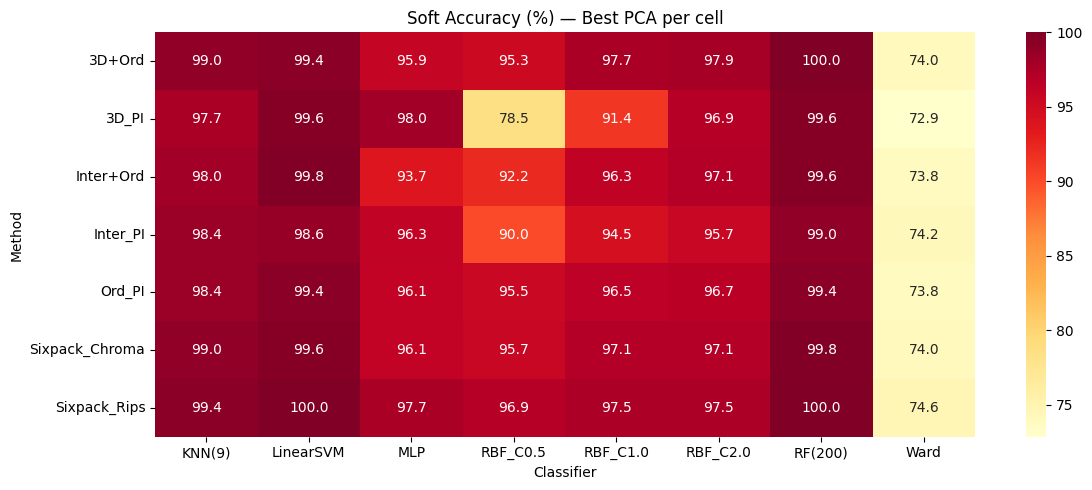

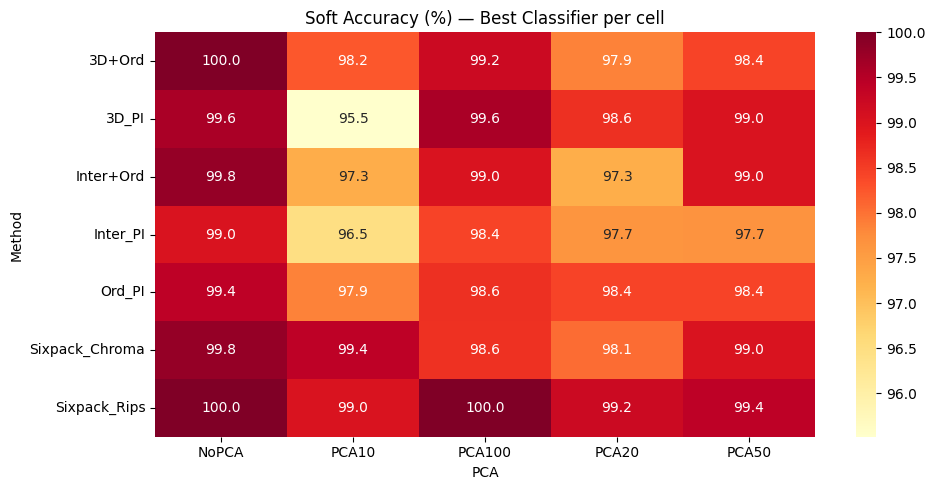

In [11]:
# Heatmap: Method × Classifier (best PCA)
import matplotlib.pyplot as plt
import seaborn as sns

pivot_heat = df.groupby(['Method','Classifier'])['Soft(%)'].max().unstack()
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_heat, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Soft Accuracy (%) — Best PCA per cell')
plt.tight_layout()
plt.savefig(os.path.join(out_path, 'heatmap_method_clf.png'), dpi=150)
plt.show()

# Heatmap: Method × PCA (best classifier)
pivot_pca = df.groupby(['Method','PCA'])['Soft(%)'].max().unstack()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_pca, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Soft Accuracy (%) — Best Classifier per cell')
plt.tight_layout()
plt.savefig(os.path.join(out_path, 'heatmap_method_pca.png'), dpi=150)
plt.show()

In [15]:
# 이미 계산된 df (full_benchmark.csv) 사용
# df = pd.read_csv(os.path.join(BASE, 'Final_Results', 'full_benchmark.csv'))

for method in METHODS:
    print(f'\n{"="*70}')
    print(f'  {method}')
    print(f'{"="*70}')
    sub = df[df['Method'] == method]
    pivot = sub.pivot(index='Classifier', columns='PCA', values='Soft(%)')
    pca_labels = [f'PCA{d}' if d else 'NoPCA' for d in [10, 20, 50, 100, None]]
    pivot = pivot[[p for p in pca_labels if p in pivot.columns]]
    print(pivot.to_string(float_format='%.1f'))



  Ord_PI
PCA         PCA10  PCA20  PCA50  PCA100  NoPCA
Classifier                                    
KNN(9)       95.7   97.8   98.4    98.2   97.9
LinearSVM    97.3   96.9   97.1    98.6   99.4
MLP          91.2   93.5   96.1    90.2   94.7
RBF_C0.5     72.9   88.3   95.5    94.9   94.1
RBF_C1.0     72.9   89.8   95.7    96.5   96.5
RBF_C2.0     73.6   92.2   95.7    96.5   96.7
RF(200)      97.9   98.4   97.3    97.7   99.4
Ward         73.8   73.6   73.6    73.6   73.6

  Inter_PI
PCA         PCA10  PCA20  PCA50  PCA100  NoPCA
Classifier                                    
KNN(9)       93.4   96.9   97.7    98.4   94.3
LinearSVM    93.8   97.3   97.5    97.7   98.6
MLP          88.3   96.3   94.3    90.2   95.3
RBF_C0.5     71.1   90.0   89.7    88.1   87.7
RBF_C1.0     70.7   93.4   93.0    94.3   94.5
RBF_C2.0     76.6   93.9   94.7    94.7   95.7
RF(200)      96.5   97.7   96.9    97.3   99.0
Ward         74.2   74.2   74.2    74.2   74.2

  3D_PI
PCA         PCA10  PCA20  PCA

In [16]:
!pip install umap-learn phate

import umap
import phate

for method in METHODS:
    X_raw = datasets[method]['X']
    y = datasets[method]['y']
    X_scaled = StandardScaler().fit_transform(X_raw)

    # PCA
    X_pca = PCA(n_components=20, random_state=42).fit_transform(X_scaled)
    s_pca = soft_accuracy(y, ward_classify(X_pca, y, N_CLASSES))*100

    # UMAP
    X_umap = umap.UMAP(n_components=20, random_state=42).fit_transform(X_scaled)
    s_umap = soft_accuracy(y, ward_classify(X_umap, y, N_CLASSES))*100

    # PHATE
    phate_op = phate.PHATE(n_components=20, random_state=42, verbose=False)
    X_phate = phate_op.fit_transform(X_scaled)
    s_phate = soft_accuracy(y, ward_classify(X_phate, y, N_CLASSES))*100

    print(f'{method:<18s}  PCA={s_pca:.1f}%  UMAP={s_umap:.1f}%  PHATE={s_phate:.1f}%')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.9/52.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 16.6 MB/s eta 0:00:00
    SGD-MDS may not have converged: stress changed by -3.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Ord_PI              PCA=73.6%  UMAP=93.2%  PHATE=83.8%
    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Inter_PI            PCA=74.2%  UMAP=91.8%  PHATE=84.4%
    SGD-MDS may not have converged: stress changed by -2.8% in final iterations. Consider increasing n_iter or adjusting learning_rate.
3D_PI               PCA=72.9%  UMAP=88.9%  PHATE=82.0%
    SGD-MDS may not have converged: stress changed by -3.3% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Sixpack_Rips        PCA=74.4%  UMAP=75.2%  PHATE=81.2%
   

In [10]:
for m in METHODS:
    X = datasets[m]['X']
    print(f'{m:<18s}: {X.shape[1]:>6d}D  ({X.shape[0]} samples)')


Ord_PI            :  10200D  (512 samples)
Inter_PI          :  10200D  (512 samples)
3D_PI             :  16800D  (512 samples)
Sixpack_Rips      :  61200D  (512 samples)
Sixpack_Chroma    :  61200D  (512 samples)
Inter+Ord         :  20400D  (512 samples)
3D+Ord            :  27000D  (512 samples)


In [18]:
!pip install phate

import phate
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# === Autoencoder ===
class AE(nn.Module):
    def __init__(self, input_dim, latent=20):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, latent),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, 64), nn.ReLU(),
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, input_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

def ae_reduce(X, latent=20, epochs=200, lr=1e-3):
    X_t = torch.FloatTensor(X)
    loader = DataLoader(TensorDataset(X_t), batch_size=64, shuffle=True)
    model = AE(X.shape[1], latent)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        for (batch,) in loader:
            recon, _ = model(batch)
            loss = nn.MSELoss()(recon, batch)
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        _, Z = model(X_t)
    return Z.numpy()

# === 실행 ===
for method in METHODS:
    X_raw = datasets[method]['X']
    y = datasets[method]['y']
    X_scaled = StandardScaler().fit_transform(X_raw)

    # 1) No reduction
    yp = ward_classify(X_scaled, y, N_CLASSES)
    s_none = soft_accuracy(y, yp)*100

    # 2) PHATE 20
    X_phate = phate.PHATE(n_components=20, random_state=42, verbose=False).fit_transform(X_scaled)
    yp = ward_classify(X_phate, y, N_CLASSES)
    s_phate = soft_accuracy(y, yp)*100

    # 3) Autoencoder 20
    X_ae = ae_reduce(X_scaled, latent=20)
    yp = ward_classify(X_ae, y, N_CLASSES)
    s_ae = soft_accuracy(y, yp)*100

    print(f'{method:<18s}  None={s_none:.1f}%  PHATE={s_phate:.1f}%  AE={s_ae:.1f}%')


    SGD-MDS may not have converged: stress changed by -3.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Ord_PI              None=73.6%  PHATE=83.8%  AE=78.5%
    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


KeyboardInterrupt: 

=== Best Configs ===
        Method    PCA Classifier    Soft(%)
        3D+Ord PCA100  LinearSVM  99.221397
         3D_PI PCA100  LinearSVM  99.611650
     Inter+Ord  PCA50  LinearSVM  99.027223
      Inter_PI PCA100     KNN(9)  98.438987
        Ord_PI PCA100  LinearSVM  98.636969
Sixpack_Chroma  PCA10  LinearSVM  99.415572
  Sixpack_Rips PCA100  LinearSVM 100.000000

Method             Classifier   PCA       Frob Norm
------------------------------------------------------------
Ord_PI             LinearSVM    PCA100        67.56
Inter_PI           KNN(9)       PCA100        62.06
3D_PI              LinearSVM    PCA100        61.43
Sixpack_Rips       LinearSVM    PCA100        61.94
Sixpack_Chroma     LinearSVM    PCA10         49.62
Inter+Ord          LinearSVM    PCA50         61.81
3D+Ord             LinearSVM    PCA100        64.65


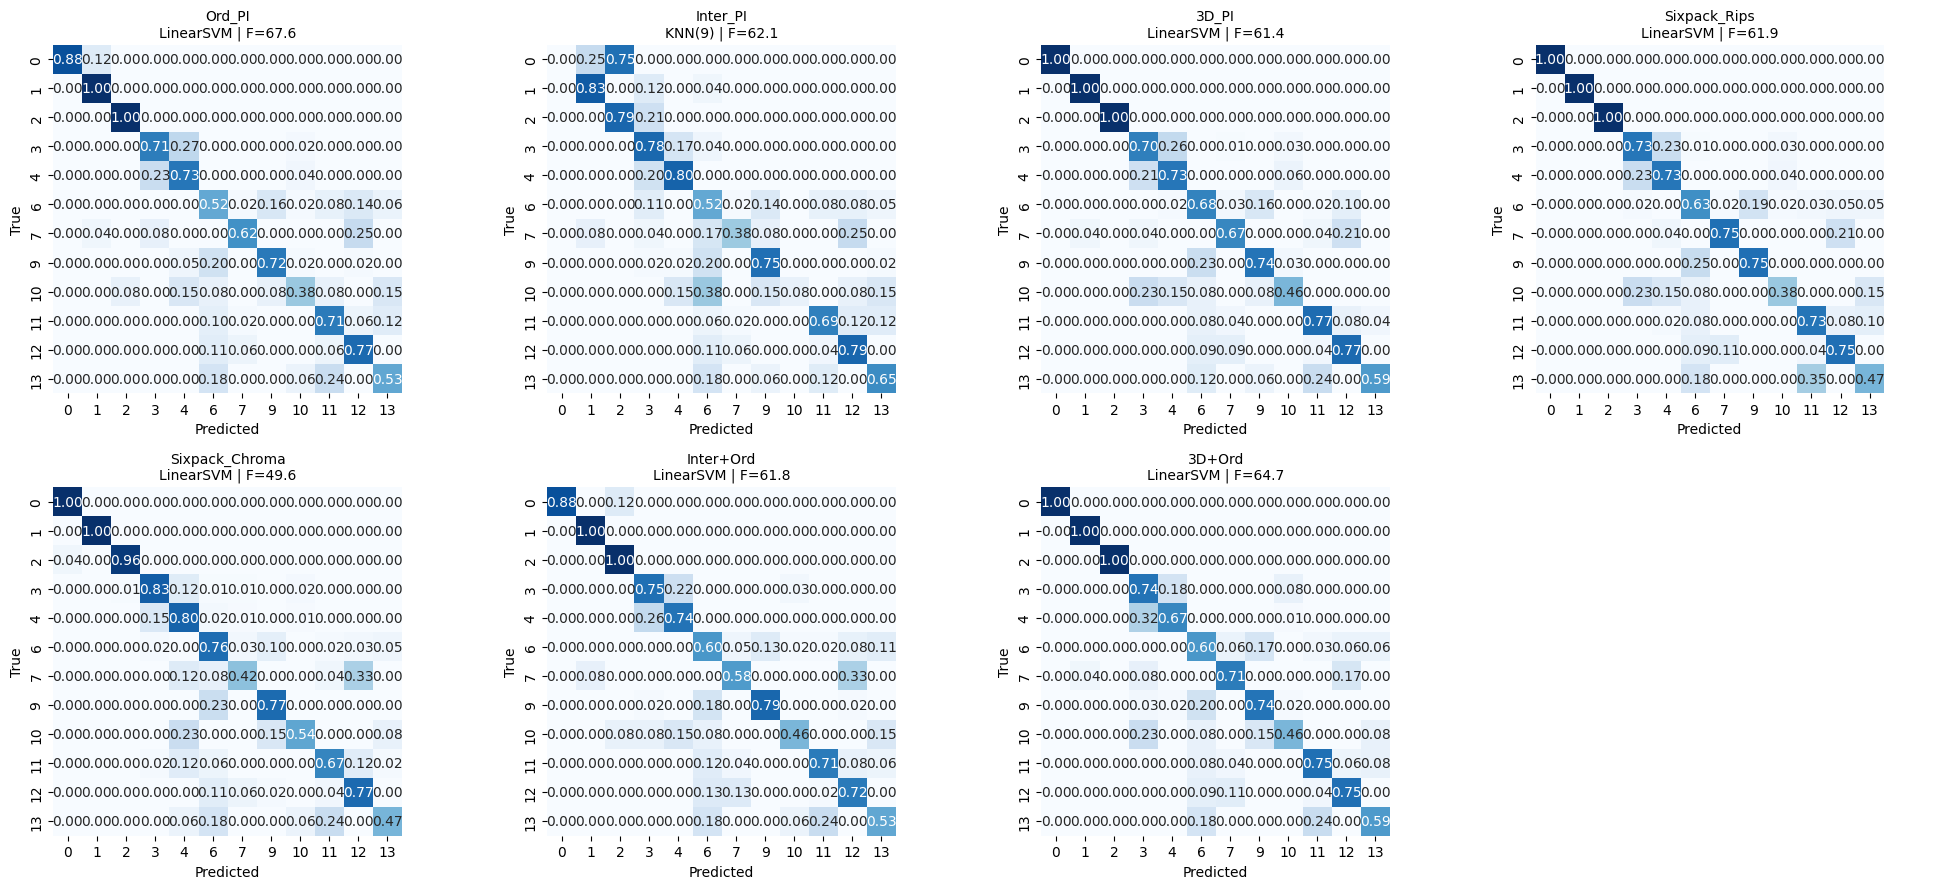

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

df_filtered = df[df['PCA'] != 'NoPCA']
best_configs = df_filtered.loc[df_filtered.groupby('Method')['Soft(%)'].idxmax()]

# PCA20 고정, best classifier per method
#df_pca20 = df[df['PCA'] == 'PCA20']
#best_configs = df_pca20.loc[df_pca20.groupby('Method')['Soft(%)'].idxmax()]


# Best classifier per method (from df)
print('=== Best Configs ===')
print(best_configs[['Method','PCA','Classifier','Soft(%)']].to_string(index=False))

# 재실행하여 confusion matrix 획득
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cm_results = {}

for _, row in best_configs.iterrows():
    method = row['Method']
    pca_dim = int(row['PCA'].replace('PCA','')) if 'PCA' in row['PCA'] and row['PCA']!='NoPCA' else None
    clf_name = row['Classifier']

    X_raw = datasets[method]['X']
    y = datasets[method]['y']
    X_scaled = StandardScaler().fit_transform(X_raw)
    if pca_dim and pca_dim < X_scaled.shape[1]:
        X = PCA(n_components=pca_dim, random_state=42).fit_transform(X_scaled)
    else:
        X = X_scaled

    if clf_name == 'Ward':
        yp = ward_classify(X, y, N_CLASSES)
    else:
        clfs = get_classifiers()
        clf = clfs[clf_name]
        # 전체 fold 예측 합산
        yp = np.zeros_like(y)
        for tr, te in skf.split(X, y):
            c = clf.__class__(**clf.get_params())
            c.fit(X[tr], y[tr])
            yp[te] = c.predict(X[te])

    cm = confusion_matrix(y, yp, labels=ALL_CLASSES)
    # Frobenius norm: ||CM - perfect||_F  (perfect = diag with row sums)
    perfect = np.diag(cm.sum(axis=1))
    frob = np.linalg.norm(cm - perfect, 'fro')
    cm_results[method] = {'cm': cm, 'frob': frob, 'clf': clf_name, 'pca': row['PCA']}

# === Frobenius Norm 표 ===
print(f'\n{"="*60}')
print(f'{"Method":<18} {"Classifier":<12} {"PCA":<8} {"Frob Norm":>10}')
print(f'{"-"*60}')
for m in METHODS:
    r = cm_results[m]
    print(f'{m:<18} {r["clf"]:<12} {r["pca"]:<8} {r["frob"]:>10.2f}')

# === Confusion Matrix 히트맵 ===
n = len(METHODS)
fig, axes = plt.subplots(2, (n+1)//2, figsize=(5*((n+1)//2), 9))
axes = axes.flatten()

for i, m in enumerate(METHODS):
    cm = cm_results[m]['cm']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[i],
                xticklabels=ALL_CLASSES, yticklabels=ALL_CLASSES, vmin=0, vmax=1,
                cbar=False, square=True)
    axes[i].set_title(f'{m}\n{cm_results[m]["clf"]} | F={cm_results[m]["frob"]:.1f}', fontsize=10)
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')

for j in range(i+1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'Final_Results', 'confusion_matrices.png'), dpi=150)
plt.show()


=== Best Configs ===
        Method   PCA Classifier   Soft(%)
        3D+Ord PCA20  LinearSVM 97.852656
         3D_PI PCA20    RF(200) 98.635066
     Inter+Ord PCA20  LinearSVM 97.268228
      Inter_PI PCA20    RF(200) 97.650866
        Ord_PI PCA20    RF(200) 98.440891
Sixpack_Chroma PCA20  LinearSVM 98.052541
  Sixpack_Rips PCA20     KNN(9) 99.219494

Method             Classifier   PCA       Frob Norm
------------------------------------------------------------
Ord_PI             RF(200)      PCA20         56.78
Inter_PI           RF(200)      PCA20         53.63
3D_PI              RF(200)      PCA20         54.44
Sixpack_Rips       KNN(9)       PCA20         55.15
Sixpack_Chroma     LinearSVM    PCA20         52.23
Inter+Ord          LinearSVM    PCA20         51.75
3D+Ord             LinearSVM    PCA20         54.99


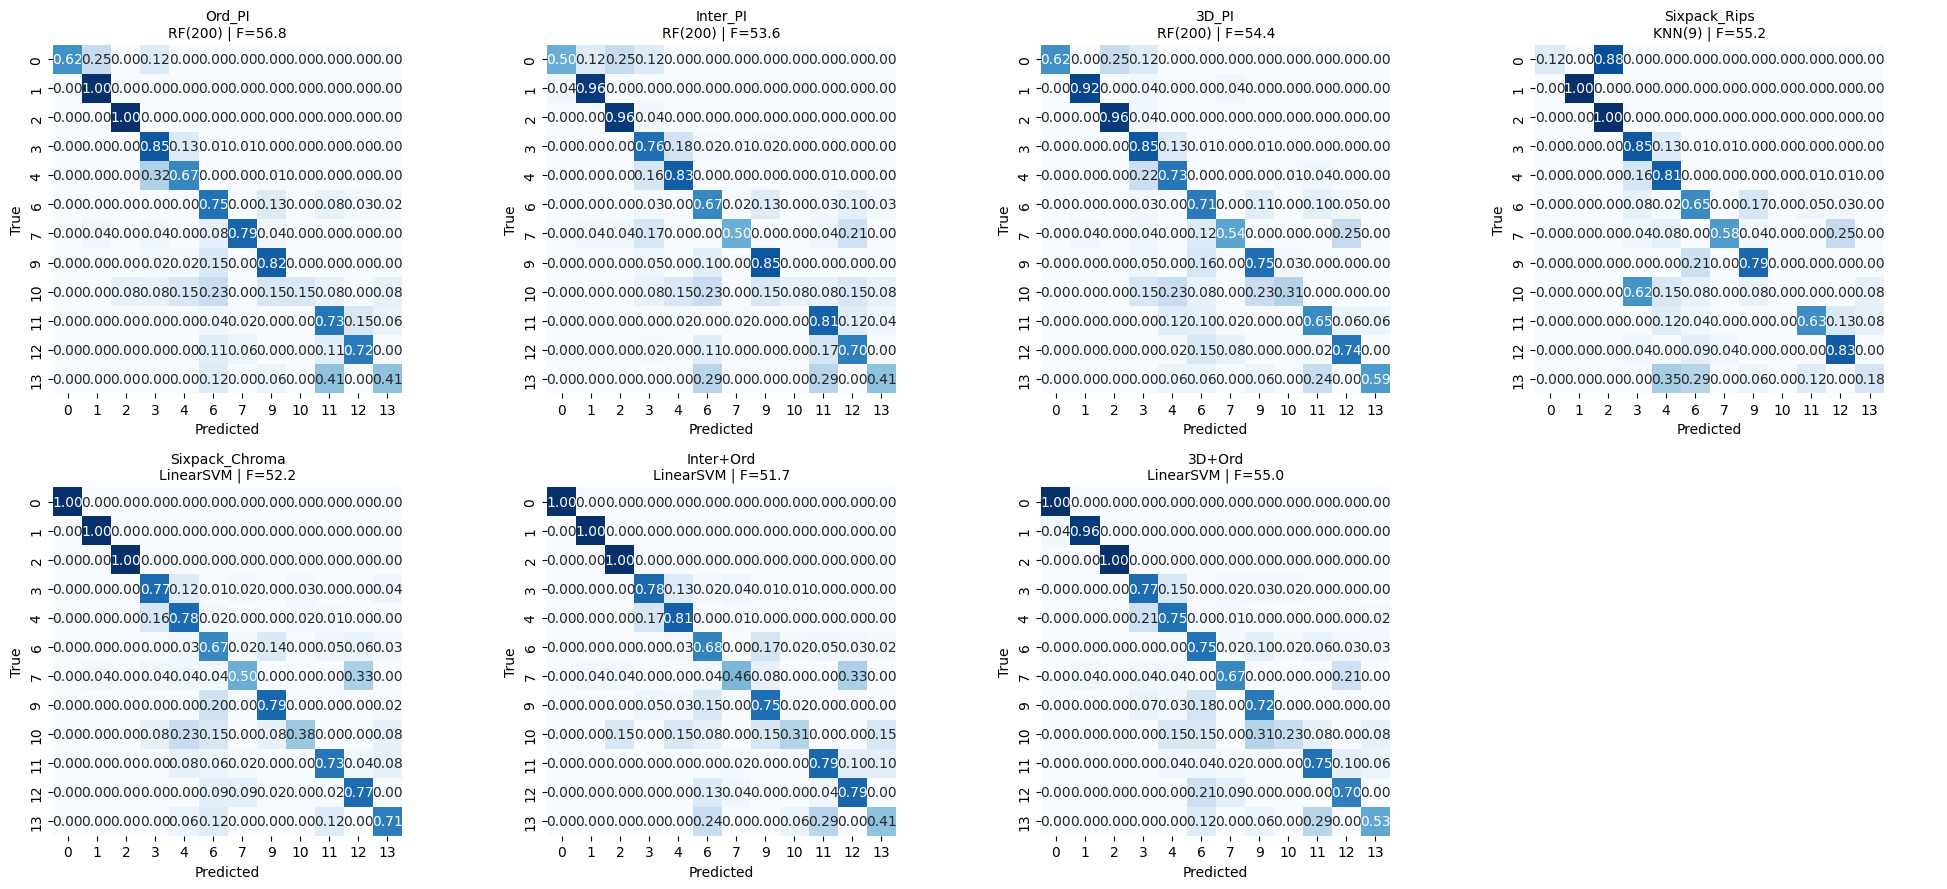

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

df_filtered = df[df['PCA'] != 'NoPCA']
best_configs = df_filtered.loc[df_filtered.groupby('Method')['Soft(%)'].idxmax()]

# PCA20 고정, best classifier per method
df_pca20 = df[df['PCA'] == 'PCA20']
best_configs = df_pca20.loc[df_pca20.groupby('Method')['Soft(%)'].idxmax()]


# Best classifier per method (from df)
print('=== Best Configs ===')
print(best_configs[['Method','PCA','Classifier','Soft(%)']].to_string(index=False))

# 재실행하여 confusion matrix 획득
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cm_results = {}

for _, row in best_configs.iterrows():
    method = row['Method']
    pca_dim = int(row['PCA'].replace('PCA','')) if 'PCA' in row['PCA'] and row['PCA']!='NoPCA' else None
    clf_name = row['Classifier']

    X_raw = datasets[method]['X']
    y = datasets[method]['y']
    X_scaled = StandardScaler().fit_transform(X_raw)
    if pca_dim and pca_dim < X_scaled.shape[1]:
        X = PCA(n_components=pca_dim, random_state=42).fit_transform(X_scaled)
    else:
        X = X_scaled

    if clf_name == 'Ward':
        yp = ward_classify(X, y, N_CLASSES)
    else:
        clfs = get_classifiers()
        clf = clfs[clf_name]
        # 전체 fold 예측 합산
        yp = np.zeros_like(y)
        for tr, te in skf.split(X, y):
            c = clf.__class__(**clf.get_params())
            c.fit(X[tr], y[tr])
            yp[te] = c.predict(X[te])

    cm = confusion_matrix(y, yp, labels=ALL_CLASSES)
    # Frobenius norm: ||CM - perfect||_F  (perfect = diag with row sums)
    perfect = np.diag(cm.sum(axis=1))
    frob = np.linalg.norm(cm - perfect, 'fro')
    cm_results[method] = {'cm': cm, 'frob': frob, 'clf': clf_name, 'pca': row['PCA']}

# === Frobenius Norm 표 ===
print(f'\n{"="*60}')
print(f'{"Method":<18} {"Classifier":<12} {"PCA":<8} {"Frob Norm":>10}')
print(f'{"-"*60}')
for m in METHODS:
    r = cm_results[m]
    print(f'{m:<18} {r["clf"]:<12} {r["pca"]:<8} {r["frob"]:>10.2f}')

# === Confusion Matrix 히트맵 ===
n = len(METHODS)
fig, axes = plt.subplots(2, (n+1)//2, figsize=(5*((n+1)//2), 9))
axes = axes.flatten()

for i, m in enumerate(METHODS):
    cm = cm_results[m]['cm']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[i],
                xticklabels=ALL_CLASSES, yticklabels=ALL_CLASSES, vmin=0, vmax=1,
                cbar=False, square=True)
    axes[i].set_title(f'{m}\n{cm_results[m]["clf"]} | F={cm_results[m]["frob"]:.1f}', fontsize=10)
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')

for j in range(i+1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'Final_Results', 'confusion_matrices.png'), dpi=150)
plt.show()


In [11]:
# PCA20 고정, best classifier per method
df_pca20 = df[df['PCA'] == 'PCA20']
best_configs = df_pca20.loc[df_pca20.groupby('Method')['Soft(%)'].idxmax()]


NameError: name 'df' is not defined

In [12]:
pca_order = ['PCA10', 'PCA20', 'PCA50', 'PCA100', 'NoPCA']

for method in METHODS:
    print(f'\n{"="*70}')
    print(f'  {method} — Strict Accuracy (%)')
    print(f'{"="*70}')
    sub = df[df['Method'] == method]
    pivot = sub.pivot(index='Classifier', columns='PCA', values='Strict(%)')
    pivot = pivot[[p for p in pca_order if p in pivot.columns]]
    print(pivot.to_string(float_format='%.1f'))



  Ord_PI — Strict Accuracy (%)


NameError: name 'df' is not defined

In [13]:
from sklearn.model_selection import RepeatedStratifiedKFold, permutation_test_score
from scipy.stats import ttest_rel, sem
import itertools

PCA_DIM = 20  # 고정

# === 1. Repeated CV (10×5-fold) ===
print('='*80)
print('1. Repeated Stratified CV (10×5-fold) — mean ± std')
print('='*80)

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
repeated_results = {}

for method in METHODS:
    X_raw = datasets[method]['X']
    y = datasets[method]['y']
    X = PCA(n_components=min(PCA_DIM, X_raw.shape[1]), random_state=42).fit_transform(
        StandardScaler().fit_transform(X_raw))

    clfs = get_classifiers()
    method_scores = {}
    for clf_name, clf_template in clfs.items():
        softs, stricts = [], []
        for tr, te in rskf.split(X, y):
            c = clf_template.__class__(**clf_template.get_params())
            c.fit(X[tr], y[tr])
            yp = c.predict(X[te])
            softs.append(soft_accuracy(y[te], yp)*100)
            stricts.append(accuracy_score(y[te], yp)*100)
        method_scores[clf_name] = {'soft': softs, 'strict': stricts}

    repeated_results[method] = method_scores
    best_clf = max(method_scores, key=lambda c: np.mean(method_scores[c]['soft']))
    s = method_scores[best_clf]['soft']
    print(f'{method:<18s} Best={best_clf:<12s} Soft={np.mean(s):.1f}% ± {np.std(s):.1f}%')

# === 2. Confidence Interval (95%) ===
print(f'\n{"="*80}')
print('2. 95% Confidence Intervals (Best Classifier)')
print('='*80)

for method in METHODS:
    scores = repeated_results[method]
    best_clf = max(scores, key=lambda c: np.mean(scores[c]['soft']))
    s = scores[best_clf]['soft']
    ci = 1.96 * sem(s)
    print(f'{method:<18s} {best_clf:<12s} {np.mean(s):.1f}% ± {ci:.1f}% (95% CI: [{np.mean(s)-ci:.1f}, {np.mean(s)+ci:.1f}])')

# === 3. Paired t-test (모든 method 쌍) ===
print(f'\n{"="*80}')
print('3. Paired t-test (Best Classifier per Method, p-values)')
print('='*80)

best_scores = {}
for method in METHODS:
    scores = repeated_results[method]
    best_clf = max(scores, key=lambda c: np.mean(scores[c]['soft']))
    best_scores[method] = scores[best_clf]['soft']

pairs = list(itertools.combinations(METHODS, 2))
print(f'{"Method A":<18s} {"Method B":<18s} {"Mean A":>7s} {"Mean B":>7s} {"t-stat":>7s} {"p-value":>8s} {"Sig":>4s}')
print('-'*75)
for a, b in pairs:
    t, p = ttest_rel(best_scores[a], best_scores[b])
    sig = '*' if p < 0.05 else ''
    sig = '**' if p < 0.01 else sig
    sig = '***' if p < 0.001 else sig
    print(f'{a:<18s} {b:<18s} {np.mean(best_scores[a]):>6.1f}% {np.mean(best_scores[b]):>6.1f}% {t:>7.2f} {p:>8.4f} {sig:>4s}')

# === 4. Permutation Test (분류기가 랜덤보다 나은지) ===
print(f'\n{"="*80}')
print('4. Permutation Test (1000 permutations, PCA20)')
print('='*80)

for method in METHODS:
    X_raw = datasets[method]['X']
    y = datasets[method]['y']
    X = PCA(n_components=min(PCA_DIM, X_raw.shape[1]), random_state=42).fit_transform(
        StandardScaler().fit_transform(X_raw))

    scores = repeated_results[method]
    best_clf_name = max(scores, key=lambda c: np.mean(scores[c]['soft']))
    clf = get_classifiers()[best_clf_name]

    score, perm_scores, p = permutation_test_score(
        clf, X, y, cv=5, n_permutations=1000, scoring='accuracy', random_state=42)
    sig = '✓ significant' if p < 0.05 else '✗ not significant'
    print(f'{method:<18s} {best_clf_name:<12s} acc={score*100:.1f}% perm_mean={np.mean(perm_scores)*100:.1f}% p={p:.4f} {sig}')

# === 요약 테이블 ===
print(f'\n{"="*80}')
print('Summary Table')
print('='*80)
print(f'{"Method":<18s} {"Best Clf":<12s} {"Soft(%)":<12s} {"95% CI":<16s} {"Perm p":<8s}')
print('-'*66)
for method in METHODS:
    scores = repeated_results[method]
    best_clf = max(scores, key=lambda c: np.mean(scores[c]['soft']))
    s = scores[best_clf]['soft']
    ci = 1.96 * sem(s)
    print(f'{method:<18s} {best_clf:<12s} {np.mean(s):.1f} ± {np.std(s):.1f}  [{np.mean(s)-ci:.1f}, {np.mean(s)+ci:.1f}]')


1. Repeated Stratified CV (10×5-fold) — mean ± std


KeyboardInterrupt: 

In [14]:
# glob 순서 확인
import glob
files = sorted(glob.glob(os.path.join(RIPS_DIR, 'Sixpack_Rips_*.npz')))
glob_order = [int(os.path.basename(f).split('_')[-1].split('.')[0]) for f in files]
print(f'Glob order: {glob_order[:10]}')  # 1, 10, 100, 101, ...
print(f'Range order: {list(range(1,11))}')  # 1, 2, 3, 4, ...


Glob order: [1, 10, 100, 101, 102, 103, 104, 105, 106, 107]
Range order: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [15]:
def load_sixpack_ablation(keys_to_use):
    files = sorted(glob.glob(os.path.join(RIPS_DIR, 'Sixpack_Rips_*.npz')))
    X_list, y_list = [], []
    for fp in files:
        sim_idx = int(os.path.basename(fp).split('_')[-1].split('.')[0])
        label = get_label(sim_idx)
        data = np.load(fp, allow_pickle=True)
        features = []
        for arr_key in sorted(data.keys()):
            d = data[arr_key].item()
            for k in sorted(k2 for k2 in d.keys() if k2 in keys_to_use):
                if isinstance(d[k], dict):
                    for dk in sorted(d[k].keys()):
                        features.extend(np.asarray(d[k][dk]).flatten())
        X_list.append(features); y_list.append(label)
    return np.nan_to_num(np.array(X_list, dtype=float)), np.array(y_list)


In [17]:
def _extract_stat_features(barcode):
    """barcode → 12-dim 통계 feature 벡터."""
    if len(barcode) == 0:
        return np.zeros(12)
    bc = np.array(barcode)
    if bc.ndim == 1:
        if len(bc) % 2 == 0:
            bc = bc.reshape(-1, 2)
        elif len(bc) > 2:
            bc = bc[:len(bc)//2*2].reshape(-1, 2)
        else:
            bc = np.array([[0., 0.]])
    if bc.ndim == 1 or bc.shape[1] < 2:
        return np.zeros(12)
    ls = bc[:, 1] - bc[:, 0]
    b, d = bc[:, 0], bc[:, 1]
    feats = [len(bc), np.mean(ls), np.std(ls), np.max(ls), np.min(ls),
             np.sum(ls), np.mean(b), np.std(b), np.mean(d), np.std(d),
             np.median(ls)]
    p = ls / np.sum(ls) if np.sum(ls) > 0 else ls
    p = p[p > 0]
    feats.append(-np.sum(p * np.log(p + 1e-10)) if len(p) > 0 else 0)
    return np.array(feats)


In [18]:
import itertools

# === Sixpack_Rips Ablation Study ===
# 6개 barcode type 중 어떤 조합이 성능에 기여하는지 분석

KEYS = ['image', 'kernel', 'cokernel', 'complex', 'sub_complex', 'relative']
RIPS_DIR = os.path.join(VECTOR_DIR, 'Sixpack_Rips')
PCA_DIM = 20

# --- 선택적 feature 로딩 ---
def load_sixpack_ablation(keys_to_use):
    BARCODE_TYPES = ['domain', 'codomain', 'relative', 'image', 'kernel', 'cokernel']
    # complex→domain, sub_complex→codomain 매핑
    KEY_MAP = {'complex': 'domain', 'sub_complex': 'codomain',
               'image': 'image', 'kernel': 'kernel',
               'cokernel': 'cokernel', 'relative': 'relative'}
    REV_MAP = {v: k for k, v in KEY_MAP.items()}

    files = sorted(glob.glob(os.path.join(RIPS_DIR, 'Sixpack_Rips_*.npz')))
    X_list, y_list = [], []
    for fp in files:
        sim_idx = int(os.path.basename(fp).split('_')[-1].split('.')[0])
        label = get_label(sim_idx)
        data = np.load(fp, allow_pickle=True)
        sp = {'A_to_B': data['arr_0'].item(), 'B_to_A': data['arr_1'].item()}
        feats = []
        for d_key in ['A_to_B', 'B_to_A']:
            dd = sp[d_key]
            for bt in BARCODE_TYPES:
                actual_key = REV_MAP.get(bt, bt)
                if actual_key not in [KEY_MAP.get(k, k) for k in keys_to_use]:
                    feats.extend(np.zeros(24))  # 2 dims × 12 stats
                    continue
                for dim_key in [0, 1]:
                    if actual_key in dd and dim_key in dd[actual_key]:
                        raw = np.array(dd[actual_key][dim_key])
                        feats.extend(_extract_stat_features(raw))
                    else:
                        feats.extend(np.zeros(12))
        X_list.append(feats); y_list.append(label)
    return np.nan_to_num(np.array(X_list)), np.array(y_list)


def evaluate(X, y):
    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=min(PCA_DIM, X_scaled.shape[1]), random_state=42).fit_transform(X_scaled)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    softs, stricts = [], []
    for tr, te in skf.split(X_pca, y):
        clf_i = SVC(kernel='linear', C=1e10)
        clf_i.fit(X_pca[tr], y[tr])
        yp = clf_i.predict(X_pca[te])
        softs.append(soft_accuracy(y[te], yp)*100)
        stricts.append(accuracy_score(y[te], yp)*100)
    return np.mean(softs), np.mean(stricts)


# === 1. 단일 (Individual) ===
print('='*60)
print('1. Individual Contribution (각 type 단독)')
print('='*60)
for k in KEYS:
    X, y = load_sixpack_ablation([k])
    s, st = evaluate(X, y)
    print(f'  {k:<15s}: dim={X.shape[1]:>6d}  Soft={s:.1f}%  Strict={st:.1f}%')

# === 2. Leave-One-Out ===
print(f'\n{"="*60}')
print('2. Leave-One-Out (하나씩 제거)')
print('='*60)
X_full, y_full = load_sixpack_ablation(KEYS)
s_full, st_full = evaluate(X_full, y_full)
print(f'  {"ALL (baseline)":<15s}: dim={X_full.shape[1]:>6d}  Soft={s_full:.1f}%  Strict={st_full:.1f}%')
print()
for k in KEYS:
    remaining = [x for x in KEYS if x != k]
    X, y = load_sixpack_ablation(remaining)
    s, st = evaluate(X, y)
    delta = s - s_full
    print(f'  -{"" + k:<14s}: dim={X.shape[1]:>6d}  Soft={s:.1f}%  (Δ={delta:+.1f}%)  Strict={st:.1f}%')

# === 3. Cumulative (하나씩 추가) ===
print(f'\n{"="*60}')
print('3. Cumulative Addition (중요도 순서 탐색)')
print('='*60)
remaining = list(KEYS)
selected = []
for step in range(len(KEYS)):
    best_k, best_s, best_st = None, -1, -1
    for k in remaining:
        X, y = load_sixpack_ablation(selected + [k])
        s, st = evaluate(X, y)
        if s > best_s:
            best_k, best_s, best_st = k, s, st
    selected.append(best_k)
    remaining.remove(best_k)
    print(f'  +{best_k:<14s} → {str(selected):<55s} Soft={best_s:.1f}%  Strict={best_st:.1f}%')

# === 4. 요약 히트맵 ===
import matplotlib.pyplot as plt
import seaborn as sns

# 2^6 - 1 = 63 조합 중 주요 조합만
combos = []
for r in range(1, len(KEYS)+1):
    for c in itertools.combinations(KEYS, r):
        combos.append(list(c))

print(f'\n{"="*60}')
print(f'4. All {len(combos)} combinations (computing...)')
print('='*60)

combo_results = []
for i, c in enumerate(combos):
    X, y = load_sixpack_ablation(c)
    s, st = evaluate(X, y)
    combo_results.append({'keys': '+'.join(c), 'n_keys': len(c), 'Soft': s, 'Strict': st})
    if (i+1) % 10 == 0: print(f'  {i+1}/{len(combos)}...')

df_abl = pd.DataFrame(combo_results).sort_values('Soft', ascending=False)
print(f'\nTop 10:')
print(df_abl.head(10)[['keys','n_keys','Soft','Strict']].to_string(index=False))
print(f'\nBottom 5:')
print(df_abl.tail(5)[['keys','n_keys','Soft','Strict']].to_string(index=False))

df_abl.to_csv(os.path.join(BASE, 'Final_Results', 'sixpack_rips_ablation.csv'), index=False)
print(f'\nSaved to Final_Results/sixpack_rips_ablation.csv')


1. Individual Contribution (각 type 단독)


KeyboardInterrupt: 

In [6]:
def load_sixpack_stats(keys_to_use=None):
    """원래 288D stat features 방식으로 로딩."""
    if keys_to_use is None:
        keys_to_use = ['image','kernel','cokernel','complex','sub_complex','relative']
    files = sorted(glob.glob(os.path.join(RIPS_DIR, 'Sixpack_Rips_*.npz')))
    X_list, y_list = [], []
    for fp in files:
        sim_idx = int(os.path.basename(fp).split('_')[-1].split('.')[0])
        label = get_label(sim_idx)
        data = np.load(fp, allow_pickle=True)
        features = []
        for arr_key in sorted(data.keys()):
            d = data[arr_key].item()
            for k in sorted(k2 for k2 in d.keys() if k2 in keys_to_use):
                if isinstance(d[k], dict):
                    for dk in sorted(d[k].keys()):
                        bars = np.asarray(d[k][dk]).flatten()
                        # 12 stats
                        if len(bars) > 0 and np.any(bars != 0):
                            features.extend([
                                len(bars), np.mean(bars), np.std(bars),
                                np.min(bars), np.max(bars), np.sum(bars),
                                np.median(bars), np.percentile(bars, 25),
                                np.percentile(bars, 75), np.var(bars),
                                np.ptp(bars), np.mean(bars**2),
                            ])
                        else:
                            features.extend([0]*12)
        X_list.append(features); y_list.append(label)
    return np.nan_to_num(np.array(X_list, dtype=float)), np.array(y_list)

# 비교
X_stat, y_stat = load_sixpack_stats()
print(f'Stat features: {X_stat.shape}')  # (512, 288)
s, st = evaluate(X_stat, y_stat)
print(f'Soft={s:.1f}%  Strict={st:.1f}%')


NameError: name 'RIPS_DIR' is not defined

In [42]:
# Ablation with stat features (288D)
print('=== Individual ===')
for k in KEYS:
    X, y = load_sixpack_stats([k])
    s, st = evaluate(X, y)
    print(f'  {k:<15s}: dim={X.shape[1]:>4d}  Soft={s:.1f}%  Strict={st:.1f}%')

print('\n=== Leave-One-Out ===')
X_full, y_full = load_sixpack_stats(KEYS)
s_full, st_full = evaluate(X_full, y_full)
print(f'  ALL:             dim={X_full.shape[1]:>4d}  Soft={s_full:.1f}%  Strict={st_full:.1f}%')
for k in KEYS:
    X, y = load_sixpack_stats([x for x in KEYS if x != k])
    s, st = evaluate(X, y)
    print(f'  -{k:<14s}: dim={X.shape[1]:>4d}  Soft={s:.1f}% (Δ={s-s_full:+.1f}%)  Strict={st:.1f}%')


=== Individual ===
  image          : dim=  48  Soft=97.7%  Strict=76.2%
  kernel         : dim=  48  Soft=97.1%  Strict=68.2%
  cokernel       : dim=  48  Soft=99.8%  Strict=75.4%
  complex        : dim=  48  Soft=93.2%  Strict=60.6%
  sub_complex    : dim=  48  Soft=97.9%  Strict=76.6%
  relative       : dim=  48  Soft=99.8%  Strict=82.0%

=== Leave-One-Out ===
  ALL:             dim= 288  Soft=99.2%  Strict=82.8%
  -image         : dim= 240  Soft=99.2% (Δ=-0.0%)  Strict=81.8%
  -kernel        : dim= 240  Soft=99.8% (Δ=+0.6%)  Strict=81.3%
  -cokernel      : dim= 240  Soft=99.4% (Δ=+0.2%)  Strict=83.6%
  -complex       : dim= 240  Soft=99.2% (Δ=+0.0%)  Strict=84.2%
  -sub_complex   : dim= 240  Soft=99.4% (Δ=+0.2%)  Strict=82.6%
  -relative      : dim= 240  Soft=99.2% (Δ=-0.0%)  Strict=81.6%


In [41]:
# 원본 (1224_Vectors) vs 재계산 (Final_Vector) 비교
ORIG_DIR = os.path.join(BASE, '1224_Vectors', 'Sixpack_Rips')
NEW_DIR = os.path.join(VECTOR_DIR, 'Sixpack_Rips')

for label, rdir in [('Original', ORIG_DIR), ('Recalculated', NEW_DIR)]:
    old_RIPS_DIR = RIPS_DIR
    RIPS_DIR = rdir
    X, y = load_sixpack_stats(KEYS)
    RIPS_DIR = old_RIPS_DIR
    s, st = evaluate(X, y)
    print(f'{label:<15s}: Soft={s:.1f}%  Strict={st:.1f}%')


Original       : Soft=99.2%  Strict=81.3%
Recalculated   : Soft=99.2%  Strict=82.8%


In [20]:
import os, numpy as np, pandas as pd

BASE = '/content/drive/MyDrive/URP'
df = pd.read_csv(os.path.join(BASE, 'Final_Results', 'full_benchmark.csv'))
METHODS = df['Method'].unique().tolist()


# === Full Benchmark 결과 테이블 출력 ===
# df 가 이미 존재한다고 가정 (full_benchmark.csv 로드 가능)
# df = pd.read_csv(os.path.join(BASE, 'Final_Results', 'full_benchmark.csv'))

from IPython.display import display, HTML

pca_order = ['PCA10', 'PCA20', 'PCA50', 'PCA100', 'NoPCA']

# ─── 1. Descriptor별 × Classifier × PCA: Soft Accuracy ───
print('=' * 90)
print('  FULL BENCHMARK — Soft Accuracy (%)')
print('=' * 90)
for method in METHODS:
    sub = df[df['Method'] == method]
    pivot = sub.pivot(index='Classifier', columns='PCA', values='Soft(%)')
    pivot = pivot[[p for p in pca_order if p in pivot.columns]]
    # Best 표시
    best_row = sub.loc[sub['Soft(%)'].idxmax()]
    print(f'\n{"─"*90}')
    print(f'  {method}  (dim={datasets[method]["X"].shape[1]})  '
          f'★ Best: {best_row["Classifier"]} @ {best_row["PCA"]} = {best_row["Soft(%)"]:.1f}%')
    print(f'{"─"*90}')
    print(pivot.to_string(float_format='%.1f'))

# ─── 2. Descriptor별 × Classifier × PCA: Strict Accuracy ───
print('\n\n' + '=' * 90)
print('  FULL BENCHMARK — Strict Accuracy (%)')
print('=' * 90)
for method in METHODS:
    sub = df[df['Method'] == method]
    pivot = sub.pivot(index='Classifier', columns='PCA', values='Strict(%)')
    pivot = pivot[[p for p in pca_order if p in pivot.columns]]
    best_row = sub.loc[sub['Strict(%)'].idxmax()]
    print(f'\n{"─"*90}')
    print(f'  {method}  '
          f'★ Best: {best_row["Classifier"]} @ {best_row["PCA"]} = {best_row["Strict(%)"]:.1f}%')
    print(f'{"─"*90}')
    print(pivot.to_string(float_format='%.1f'))

# ─── 3. 요약 테이블: Best per Method ───
print('\n\n' + '=' * 90)
print('  SUMMARY — Best per Method')
print('=' * 90)
summary_rows = []
for method in METHODS:
    sub = df[df['Method'] == method]
    best_soft = sub.loc[sub['Soft(%)'].idxmax()]
    best_strict = sub.loc[sub['Strict(%)'].idxmax()]
    summary_rows.append({
        'Method': method,
        'Dim': datasets[method]['X'].shape[1],
        'Best_Clf(Soft)': best_soft['Classifier'],
        'Best_PCA(Soft)': best_soft['PCA'],
        'Soft(%)': best_soft['Soft(%)'],
        'Best_Clf(Strict)': best_strict['Classifier'],
        'Best_PCA(Strict)': best_strict['PCA'],
        'Strict(%)': best_strict['Strict(%)'],
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False, float_format='%.1f'))

# ─── 4. PCA 20 고정 요약 ───
print('\n\n' + '=' * 90)
print('  PCA20 고정 — Method × Classifier')
print('=' * 90)
df20 = df[df['PCA'] == 'PCA20']
pivot20 = df20.pivot(index='Method', columns='Classifier', values='Soft(%)')
print(pivot20.to_string(float_format='%.1f'))

# ─── 5. Method × PCA Best Classifier 요약 ───
print('\n\n' + '=' * 90)
print('  Best Soft(%) per Method × PCA')
print('=' * 90)
pivot_best = df.groupby(['Method', 'PCA'])['Soft(%)'].max().unstack()
pivot_best = pivot_best[[p for p in pca_order if p in pivot_best.columns]]
print(pivot_best.to_string(float_format='%.1f'))


  FULL BENCHMARK — Soft Accuracy (%)

──────────────────────────────────────────────────────────────────────────────────────────
  Ord_PI  (dim=10200)  ★ Best: LinearSVM @ NoPCA = 99.4%
──────────────────────────────────────────────────────────────────────────────────────────
PCA         PCA10  PCA20  PCA50  PCA100  NoPCA
Classifier                                    
KNN(9)       95.7   97.8   98.4    98.2   97.9
LinearSVM    97.3   96.9   97.1    98.6   99.4
MLP          91.2   93.5   96.1    90.2   94.7
RBF_C0.5     72.9   88.3   95.5    94.9   94.1
RBF_C1.0     72.9   89.8   95.7    96.5   96.5
RBF_C2.0     73.6   92.2   95.7    96.5   96.7
RF(200)      97.9   98.4   97.3    97.7   99.4
Ward         73.8   73.6   73.6    73.6   73.6

──────────────────────────────────────────────────────────────────────────────────────────
  Inter_PI  (dim=10200)  ★ Best: RF(200) @ NoPCA = 99.0%
──────────────────────────────────────────────────────────────────────────────────────────
PCA         P